# Last couple of plots for thesis

In [51]:
from fbm import FBM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from scipy import stats, signal
from scipy.stats import linregress

from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

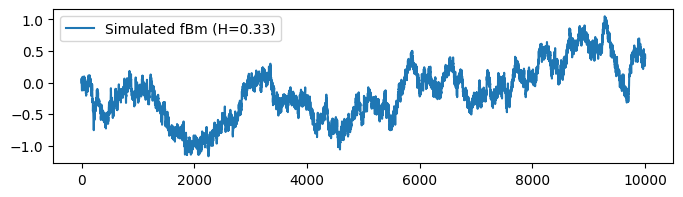

In [ ]:
# Simulate fractional Brownian motion
np.random.seed(43)

n = 50000  # Number of points

hurst = 1 / 3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1)
ts_sim = fbm_sim.fbm()[:n]

plt.figure(figsize=(8, 2))
plt.plot(ts_sim, label=f"Simulated fBm (H={hurst:.2f})")
plt.legend()

In [53]:
# Read in cleaned Voyager 1 data
df = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
print("Loaded dataset")

Loaded dataset


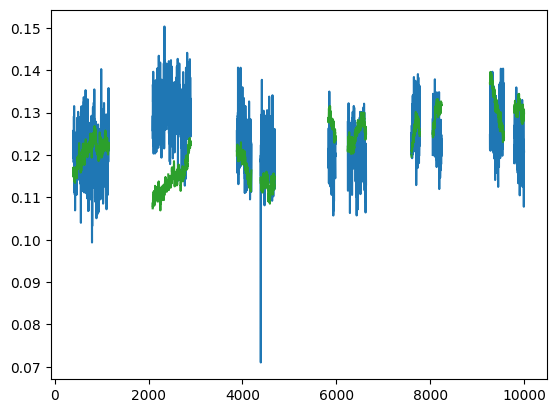

In [54]:
# Set simulated data to NaN where Voyager 1 data is missing
v1_subset = df.BR[:n]
v1_missing_mask = v1_subset.isna()

ts_sim_v1_gaps = ts_sim.copy()
ts_sim_v1_gaps[v1_missing_mask] = (
    np.nan
)

# Normalize the simulated data to match the mean and standard deviation of the Voyager 1 data
ts_sim_v1_gaps_std = ts_sim_v1_gaps / np.nanstd(ts_sim_v1_gaps) * np.nanstd(
    v1_subset
) + np.nanmean(v1_subset)

plt.plot(v1_subset.values, label="Voyager 1 LISM", color="C0")
plt.plot(ts_sim_v1_gaps_std, label="Simulated fBm", color="C2")


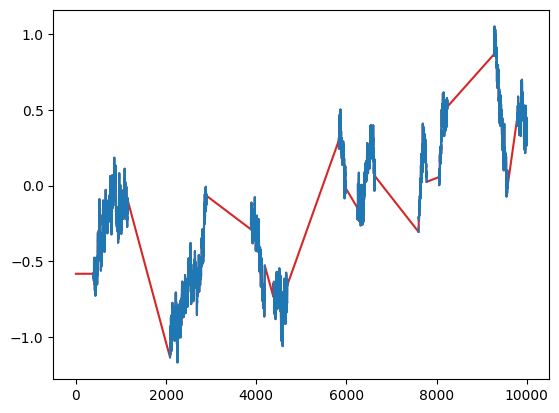

In [55]:
ts_sim_v1_gaps_lint = pd.DataFrame(
    ts_sim_v1_gaps, index=df.index[:n], columns=["Simulated fBm"])

ts_sim_v1_gaps_lint = ts_sim_v1_gaps_lint.interpolate(
    method="linear", limit_direction="both", axis=0)

plt.plot(ts_sim_v1_gaps_lint.values, label="Interpolated fBm", color="C3")
plt.plot(ts_sim_v1_gaps)

In [56]:
v1_subset_lint = v1_subset.interpolate(
    method="linear", limit_direction="both", axis=0)

In [ ]:
# # Get SF func and compare these two against full ts_sim


# sf_sim_v1_gaps = sf_funcs.compute_sf(
#     pd.DataFrame(ts_sim_v1_gaps), np.arange(1, max_lag + 1), [2], False, False, None
# ).sf_2

# sf_sim_v1_lint = sf_funcs.compute_sf(
#     pd.DataFrame(ts_sim_v1_gaps_lint.values),
#     np.arange(1, max_lag + 1),
#     [2],
#     False,
#     False,
#     None,
# ).sf_2

# sf_v1 = sf_funcs.compute_sf(
#     pd.DataFrame(v1_subset), np.arange(1, max_lag + 1), [2], False, False, None
# ).sf_2

# sf_v1_lint = sf_funcs.compute_sf(
#     pd.DataFrame(v1_subset_lint), np.arange(1, max_lag + 1), [2], False, False, None
# ).sf_2

# sf_sim = sf_funcs.compute_sf(
#     pd.DataFrame(ts_sim), np.arange(1, max_lag + 1), [2], False, False, None
# ).sf_2

In [85]:
max_lag = n/2

In [86]:
sf_sim_v1_gaps = sf_funcs.compute_sf_fast(
    pd.DataFrame(ts_sim_v1_gaps), np.arange(1, max_lag + 1), [2], False
)

sf_sim_v1_lint = sf_funcs.compute_sf_fast(
    pd.DataFrame(ts_sim_v1_gaps_lint.values),
    np.arange(1, max_lag + 1),
    [2],
    False,
)

sf_v1 = sf_funcs.compute_sf_fast(
    pd.DataFrame(v1_subset), np.arange(1, max_lag + 1), [2], False
)

sf_v1_lint = sf_funcs.compute_sf_fast(
    pd.DataFrame(v1_subset_lint), np.arange(1, max_lag + 1), [2], False
)


sf_sim = sf_funcs.compute_sf_fast(
    pd.DataFrame(ts_sim), np.arange(1, max_lag + 1), [2], False,)

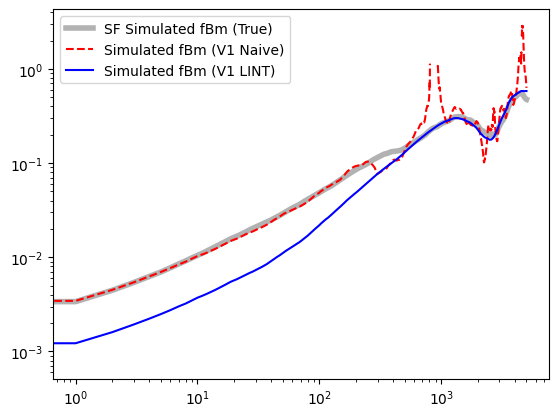

In [87]:
plt.loglog(sf_sim, label="SF Simulated fBm (True)", color="black", lw=4, alpha=0.3)
plt.loglog(
    sf_sim_v1_gaps, label="Simulated fBm (V1 Naive)", color="red", linestyle="--"
)
plt.loglog(
    sf_sim_v1_lint, label="Simulated fBm (V1 LINT)", color="blue",
)
plt.legend()

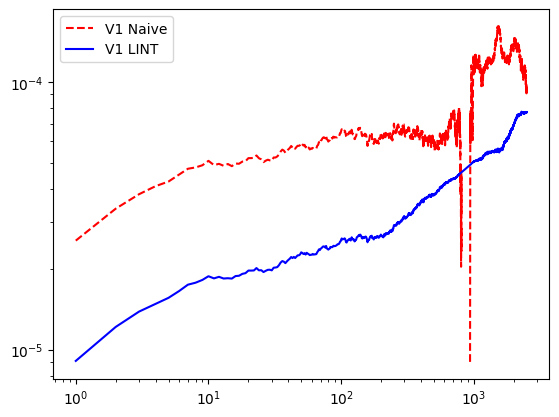

In [77]:
plt.loglog(sf_v1, label="V1 Naive", color="red", linestyle="--")
plt.loglog(sf_v1_lint, label="V1 LINT", color="blue")
plt.legend()

## Run loop for multiple gap types
Just need to get gapping fn from latest pipeline

In [60]:
# Gap ts_sim in other ways, using our standard function
# Gap between 60%, 70%, 80%, combinations of contiguous and uniform, and V1 gap mask.

results_df = pd.DataFrame(columns=["gap_fraction", "ts_gapped", "sf", "gap_handling"])

gap_handling = "naive"  # Placeholder for gap handling method

for gap_fraction in [0.6, 0.7, 0.8, "voyager"]:

    ts_sim_gapped = ts_sim.copy()

    if gap_fraction == "voyager":
        # Use the Voyager 1 missing mask
        gap_mask = v1_missing_mask.values
        ts_sim_gapped[v1_missing_mask] = np.nan

    else:
        # Create a random gap mask based on the specified fraction
        ts_sim_gapped = gap_ts(ts_sim_gapped, gap_mask)

    sf = structure_function(ts_gapped, lag=1)

    results_df = results_df.append({
        "gap_fraction": gap_fraction,
        "ts_gapped": ts_gapped,
        "sf": sf,
        "gap_handling": gap_handling
    }, ignore_index=True)

NameError: name 'gap_ts' is not defined

In [ ]:
import seaborn as sns

# Plot line plots, coloured by gap fraction
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="lag", y="sf", hue="gap_fraction", style="gap_handling")
plt.title("Structure Function with Different Gap Fractions")